<a href="https://colab.research.google.com/github/Git-Version-Control/IBM-AI-Engineer-Assignment/blob/Capstone-Project/Crack_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!wget https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/DL0321EN/data/images/Positive_tensors.zip

--2025-07-15 04:36:57--  https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/DL0321EN/data/images/Positive_tensors.zip
Resolving s3-api.us-geo.objectstorage.softlayer.net (s3-api.us-geo.objectstorage.softlayer.net)... 67.228.254.196
Connecting to s3-api.us-geo.objectstorage.softlayer.net (s3-api.us-geo.objectstorage.softlayer.net)|67.228.254.196|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2598656062 (2.4G) [application/zip]
Saving to: ‘Positive_tensors.zip’

Positive_tensors.zi 100%[===================>]   2.42G  50.5MB/s    in 42s     

2025-07-15 04:37:40 (58.5 MB/s) - ‘Positive_tensors.zip’ saved [2598656062/2598656062]



In [2]:
!unzip -qo Positive_tensors.zip

In [3]:
! wget https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/DL0321EN/data/images/Negative_tensors.zip

--2025-07-15 04:39:53--  https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/DL0321EN/data/images/Negative_tensors.zip
Resolving s3-api.us-geo.objectstorage.softlayer.net (s3-api.us-geo.objectstorage.softlayer.net)... 67.228.254.196
Connecting to s3-api.us-geo.objectstorage.softlayer.net (s3-api.us-geo.objectstorage.softlayer.net)|67.228.254.196|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2111408108 (2.0G) [application/zip]
Saving to: ‘Negative_tensors.zip’

Negative_tensors.zi 100%[===================>]   1.97G  56.7MB/s    in 45s     

2025-07-15 04:40:38 (44.3 MB/s) - ‘Negative_tensors.zip’ saved [2111408108/2111408108]



In [4]:
!unzip -qo Negative_tensors.zip

In [5]:
!pip install torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 94.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 81.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 58.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 21.2 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [6]:
# These are the libraries will be used for this lab.
import torchvision.models as models
from PIL import Image
import pandas
from torchvision import transforms
import torch.nn as nn
import time
import torch
import matplotlib.pylab as plt
import numpy as np
from torch.utils.data import Dataset, DataLoader
import h5py
import os
import glob
torch.manual_seed(0)

In [ ]:
from matplotlib.pyplot import imshow
import matplotlib.pylab as plt
from PIL import Image
import pandas as pd
import os

In [8]:
# Create your own dataset object

class Dataset(Dataset):

    # Constructor
    def __init__(self,transform=None,train=True):
        directory=""
        positive="Positive_tensors"
        negative='Negative_tensors'

        positive_file_path=os.path.join(directory,positive)
        negative_file_path=os.path.join(directory,negative)
        positive_files=[os.path.join(positive_file_path,file) for file in os.listdir(positive_file_path) if file.endswith(".pt")]
        negative_files=[os.path.join(negative_file_path,file) for file in os.listdir(negative_file_path) if file.endswith(".pt")]
        number_of_samples=len(positive_files)+len(negative_files)
        self.all_files=[None]*number_of_samples
        self.all_files[::2]=positive_files
        self.all_files[1::2]=negative_files
        # The transform is goint to be used on image
        self.transform = transform
        #torch.LongTensor
        self.Y=torch.zeros([number_of_samples]).type(torch.LongTensor)
        self.Y[::2]=1
        self.Y[1::2]=0

        if train:
            self.all_files=self.all_files[0:30000]
            self.Y=self.Y[0:30000]
            self.len=len(self.all_files)
        else:
            self.all_files=self.all_files[30000:]
            self.Y=self.Y[30000:]
            self.len=len(self.all_files)

    # Get the length
    def __len__(self):
        return self.len

    # Getter
    def __getitem__(self, idx):

        image=torch.load(self.all_files[idx])
        y=self.Y[idx]

        # If there is any transform method, apply it onto the image
        if self.transform:
            image = self.transform(image)

        return image, y

print("done")

done


In [9]:
train_dataset = Dataset(train=True)
validation_dataset = Dataset(train=False)
print("done")

done


In [10]:
# Step 1: Load the pre-trained model resnet18

# Type your code here
model=models.resnet18(pretrained=True)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 117MB/s]


In [11]:
for param in model.parameters():
    param.requires_grad = False

In [12]:
model.fc = nn.Linear(in_features=512, out_features=2)

In [13]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [14]:
criterion = nn.CrossEntropyLoss()

In [15]:
train_loader = DataLoader(dataset=train_dataset, batch_size=100, shuffle=True)
validation_loader = DataLoader(dataset=validation_dataset, batch_size=100, shuffle=False)

In [16]:
optimizer = torch.optim.Adam([parameters  for parameters in model.parameters() if parameters.requires_grad],lr=0.001)

In [17]:
n_epochs=1
loss_list=[]
accuracy_list=[]
correct=0
N_test=len(validation_dataset)
N_train=len(train_dataset)
start_time = time.time()
#n_epochs

Loss=0
start_time = time.time()
for epoch in range(n_epochs):
    model.train()
    for x, y in train_loader:

        #clear gradient
        optimizer.zero_grad()

        #make a prediction
        z = model(x)

        # calculate loss
        loss = criterion(z, y)

        # calculate gradients of parameters
        loss.backward()

        # update parameters
        optimizer.step()

        loss_list.append(loss.data)
    print('training completed')
correct=0
for x_test, y_test in validation_loader:
    # set model to eval
    model.eval()
    z = model(x_test)
    _, yhat = torch.max(z.data, 1)
    correct += (yhat == y_test).sum().item()

    #Calculate misclassified  samples in mini-batch
    #hint +=(yhat==y_test).sum().item()
print('validation complete')

accuracy=correct/N_test
accuracy_list.append(accuracy)

training completed
validation complete


In [18]:
accuracy

0.9941

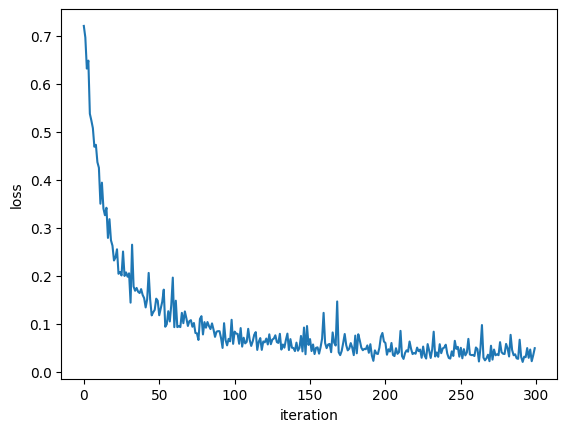

In [19]:
plt.plot(loss_list)
plt.xlabel("iteration")
plt.ylabel("loss")
plt.show()


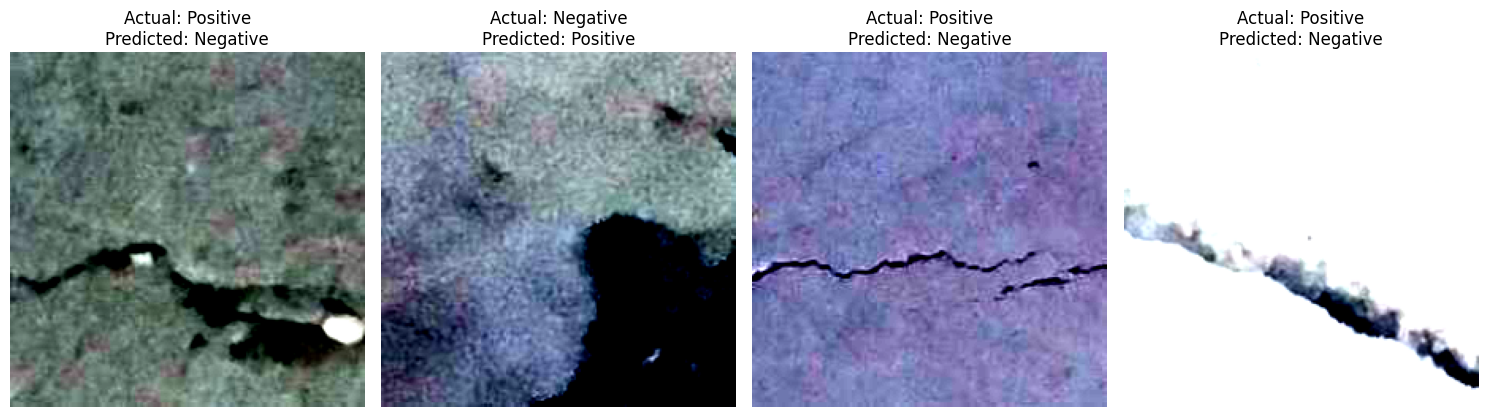

In [20]:
def identify_misclassified_samples(model, validation_loader, num_samples=4):
    model.eval()
    misclassified_samples = []

    with torch.no_grad():
        for batch_idx, (x_test, y_test) in enumerate(validation_loader):
            z = model(x_test)
            _, yhat = torch.max(z.data, 1)

            misclassified_mask = (yhat != y_test)
            misclassified_indices = torch.where(misclassified_mask)[0]

            for idx in misclassified_indices:
                if len(misclassified_samples) < num_samples:
                    sample_info = {
                        'image': x_test[idx],
                        'true_label': y_test[idx].item(),
                        'predicted_label': yhat[idx].item(),
                        'batch_idx': batch_idx,
                        'sample_idx': idx.item()
                    }
                    misclassified_samples.append(sample_info)
                else:
                    break

            if len(misclassified_samples) >= num_samples:
                break

    return misclassified_samples

misclassified = identify_misclassified_samples(model, validation_loader, num_samples=4)



In [24]:
def identify_misclassified_samples(model, validation_loader, num_samples=4):
    model.eval()
    misclassified_samples = []

    with torch.no_grad():
        for batch_idx, (x_test, y_test) in enumerate(validation_loader):
            z = model(x_test)
            _, yhat = torch.max(z.data, 1)

            misclassified_mask = (yhat != y_test)
            misclassified_indices = torch.where(misclassified_mask)[0]

            for idx in misclassified_indices:
                if len(misclassified_samples) < num_samples:
                    sample_info = {
                        'image': x_test[idx],
                        'true_label': y_test[idx].item(),
                        'predicted_label': yhat[idx].item(),
                        'batch_idx': batch_idx,
                        'sample_idx': idx.item()
                    }
                    misclassified_samples.append(sample_info)
                else:
                    break

            if len(misclassified_samples) >= num_samples:
                break

    return misclassified_samples

misclassified = identify_misclassified_samples(model, validation_loader, num_samples=4)

In [25]:
def display_misclassified_samples(samples):
    for i, sample in enumerate(samples):
        print(f"sample{i} predicted value: tensor([{sample['predicted_label']}])  actual value: tensor([{sample['true_label']}])")
display_misclassified_samples(misclassified)


sample0 predicted value: tensor([0])  actual value: tensor([1])
sample1 predicted value: tensor([1])  actual value: tensor([0])
sample2 predicted value: tensor([0])  actual value: tensor([1])
sample3 predicted value: tensor([0])  actual value: tensor([1])


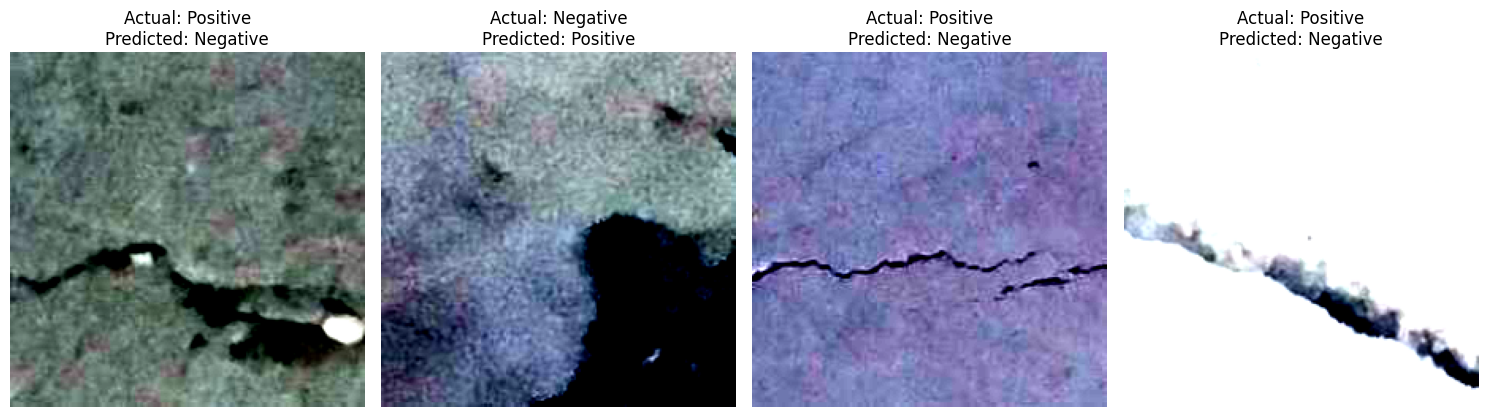

In [26]:
fig, axes = plt.subplots(1, len(misclassified), figsize=(15, 4))
if len(misclassified) == 1:
    axes = [axes]

for i, sample in enumerate(misclassified):
    image = sample['image']
    true_class = "Positive" if sample['true_label'] == 1 else "Negative"
    pred_class = "Positive" if sample['predicted_label'] == 1 else "Negative"

    if len(image.shape) == 3:
        if image.shape[0] in [1, 3]:  # Channel first format
            image = image.permute(1, 2, 0)
        if image.shape[2] == 1:  # Grayscale
            image = image.squeeze(2)

    axes[i].imshow(image, cmap='gray' if len(image.shape) == 2 else None)
    axes[i].set_title(f'Actual: {true_class}\nPredicted: {pred_class}', fontsize=12)
    axes[i].axis('off')

plt.tight_layout()
plt.show()